**This notebook converts raw START continuous task features into a single latent ability score (`start_ability`) per child using an IRT-style VAE with a linear Gaussian factor decoder.**

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset

DATA_PATH = "START.csv"
OUTPUT_PATH = "start_Deep_ability.csv"

# All 16 continuous task features
FEATURE_COLS = [
    "wt.PROP_TIME", "wt.MEDIAN_DISTANCE", "wt.STD_DISTANCE",
    "plt.SOC_PROP",
    "bt.soc_pref",
    "mft.rmse", "mft.jerk",
    "ct.crossover_counts",
    "bpt.mean_size", "bpt.mean_euclid", "bpt.time_taken",
    "st.tapinterval_400_dist", "st.tapinterval_600_dist",
    "st.mean_resultant_length_400", "st.mean_resultant_length_600",
    "dgt.propDelay",
]

LATENT_DIM  = 1
EPOCHS      = 200
BATCH_SIZE  = 64
LEARNING_RATE = 1e-3
TEST_SIZE   = 0.05
RANDOM_STATE = 42
SHOW_PLOTS  = True

# Loss weights
BETA  = 0.1   # KL weight
GAMMA = 0.0   # age-prediction MSE weight
DELTA = 0.0   # age-predictor weight uniformity penalty

In [28]:
def prepare_start_inputs(df):
    """Extract features, build observed mask, re-standardize, clip outliers, normalize age."""
    df = df.copy().reset_index(drop=True)

    ages_days  = df["Age"].to_numpy(dtype=np.float32)
    ages_years = ages_days / 365.0
    ids        = df["child_ids"].astype(str).to_numpy()
    row_id     = df.index.to_numpy()

    feat_df = df[FEATURE_COLS]

    # pd.read_csv converts empty cells to float NaN — use pandas notna() to build the mask
    # correctly; fillna(0) makes missing entries numerically safe before standardization.
    M = feat_df.notna().to_numpy(dtype=np.float32)          # 1 = observed, 0 = missing
    X = feat_df.fillna(0.0).to_numpy(dtype=np.float32)      # missing → 0 (temp placeholder)

    # Re-standardize each feature over its observed values so all features share
    # the same scale (wt.PROP_TIME is a raw proportion; others are already z-scores).
    # After standardization, missing entries (still 0) correctly equal the feature mean.
    # Clip to [-5, 5] to neutralize mft.rmse's -9.4 std outlier.
    CLIP = 5.0
    feat_means = np.zeros(len(FEATURE_COLS), dtype=np.float32)
    feat_stds  = np.ones(len(FEATURE_COLS),  dtype=np.float32)
    for j in range(len(FEATURE_COLS)):
        obs = X[:, j][M[:, j] == 1]
        if len(obs) > 1:
            feat_means[j] = float(obs.mean())
            feat_stds[j]  = float(obs.std()) if obs.std() > 0 else 1.0

    for j in range(len(FEATURE_COLS)):
        obs_idx = M[:, j] == 1
        X[obs_idx, j] = (X[obs_idx, j] - feat_means[j]) / feat_stds[j]

    X = np.clip(X, -CLIP, CLIP)

    print(f"Rows: {len(df)}  |  Features: {len(FEATURE_COLS)}")
    obs_rates = M.mean(axis=0)
    for col, rate in zip(FEATURE_COLS, obs_rates):
        print(f"  {col}: {rate*100:.1f}% observed")
    print(f"  → rows with 0 observed features: {int((M.sum(axis=1)==0).sum())}")

    return {
        "row_id":     row_id,
        "ids":        ids,
        "ages_days":  ages_days,
        "ages_years": ages_years,
        "X":          X,
        "M":          M,
        "feat_means": feat_means,
        "feat_stds":  feat_stds,
    }

In [29]:
class StartDataset(Dataset):
    """Dataset of continuous features, observation masks, and normalized age."""

    def __init__(self, X, M, age):
        self.X   = torch.tensor(X,   dtype=torch.float32)
        self.M   = torch.tensor(M,   dtype=torch.float32)
        self.age = torch.tensor(age, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.M[idx], self.age[idx]

In [30]:
class Encoder(nn.Module):
    """Maps (features, mask, age) → (mu, logvar, age_hat)."""

    def __init__(self, num_features, hidden_dims=(64, 32), latent_dim=1):
        super().__init__()
        input_dim = 2 * num_features + 1
        dims = [input_dim] + list(hidden_dims)
        self.mlp = nn.ModuleList(
            [nn.Linear(dims[i], dims[i + 1]) for i in range(len(dims) - 1)]
        )
        self.fc_mu         = nn.Linear(hidden_dims[-1], latent_dim)
        self.fc_logvar     = nn.Linear(hidden_dims[-1], latent_dim)
        self.age_predictor = nn.Linear(latent_dim, 1)

    def forward(self, x, m, age):
        h = torch.cat([x, m, age], dim=-1)
        for layer in self.mlp:
            h = torch.tanh(layer(h))
        mu = self.fc_mu(h)
        # Clamp logvar to prevent exp() overflow → KL → NaN
        logvar = self.fc_logvar(h).clamp(-4.0, 4.0)
        age_hat = self.age_predictor(mu)
        return mu, logvar, age_hat


class Decoder(nn.Module):
    """
    Linear Gaussian factor model (continuous analogue of IRT):
        x_hat_j = a_j * theta + b_j
    a = factor loadings (like IRT discrimination)
    b = feature intercepts (like IRT difficulty)
    """

    def __init__(self, num_features, latent_dim=1):
        super().__init__()
        self.a = nn.Parameter(torch.randn(num_features, latent_dim) * 0.1)
        self.b = nn.Parameter(torch.zeros(num_features))

    def forward(self, theta):
        return torch.matmul(theta, self.a.T) + self.b

In [31]:
def kl_divergence(mu, logvar):
    return (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp())).sum(dim=1).mean()


def masked_mse_loss(pred, target, mask):
    """MSE only over observed entries."""
    diff2 = (pred - target).pow(2) * mask
    return diff2.sum() / mask.sum().clamp(min=1)


def age_weight_uniformity_loss(weight, lambda_var=1.0, lambda_neg=0.0):
    """Encourage age-predictor weights to be uniform (and optionally non-negative)."""
    w = weight.view(-1)
    variance_penalty   = ((w - w.mean()) ** 2).sum()
    negativity_penalty = F.relu(-w).sum()
    return lambda_var * variance_penalty + lambda_neg * negativity_penalty


def elbo_loss(mu, logvar, pred, x, m, age_hat, age_tensor, encoder,
              beta=BETA, gamma=GAMMA, delta=DELTA):
    recon     = masked_mse_loss(pred, x, m)
    kl        = kl_divergence(mu, logvar)
    age_loss  = F.mse_loss(age_hat.view(-1), age_tensor.view(-1))
    uniformity = age_weight_uniformity_loss(encoder.age_predictor.weight)
    total = recon + beta * kl + gamma * age_loss + delta * uniformity
    return total, recon, kl, age_loss

In [32]:
def train_and_score(inputs, show_plots=SHOW_PLOTS):
    X          = inputs["X"]
    M          = inputs["M"]
    ages_days  = inputs["ages_days"]
    ages_years = inputs["ages_years"]
    num_features = X.shape[1]

    train_idx, test_idx = train_test_split(
        np.arange(len(X)), test_size=TEST_SIZE,
        random_state=RANDOM_STATE, shuffle=True,
    )

    X_train, X_test = X[train_idx], X[test_idx]
    M_train, M_test = M[train_idx], M[test_idx]
    ages_tr, ages_te = ages_days[train_idx], ages_days[test_idx]

    age_mean = ages_tr.mean()
    age_std  = ages_tr.std()

    ages_tr_n  = ((ages_tr  - age_mean) / age_std).astype(np.float32)
    ages_te_n  = ((ages_te  - age_mean) / age_std).astype(np.float32)
    ages_all_n = ((ages_days - age_mean) / age_std).astype(np.float32)

    print(f"Train: {len(train_idx)}  Test: {len(test_idx)}")
    print(f"Age norm — mean: {age_mean:.1f} days, std: {age_std:.1f} days")

    torch.manual_seed(RANDOM_STATE)
    encoder = Encoder(num_features=num_features, latent_dim=LATENT_DIM)
    decoder = Decoder(num_features=num_features, latent_dim=LATENT_DIM)

    params    = list(encoder.parameters()) + list(decoder.parameters())
    optimizer = Adam(params, lr=LEARNING_RATE)

    loader = DataLoader(
        StartDataset(X_train, M_train, ages_tr_n),
        batch_size=BATCH_SIZE, shuffle=True,
    )

    # ── training loop ──────────────────────────────────────────────────────────
    for epoch in range(EPOCHS):
        encoder.train(); decoder.train()
        tot_loss = tot_recon = tot_kl = tot_age = 0.0

        for x_b, m_b, age_b in loader:
            optimizer.zero_grad()
            mu, logvar, age_hat = encoder(x_b, m_b, age_b)
            pred = decoder(mu)
            loss, recon, kl, age_loss = elbo_loss(
                mu, logvar, pred, x_b, m_b, age_hat, age_b, encoder
            )
            loss.backward()
            # Clip gradients to prevent explosion from high-MSE outlier samples
            torch.nn.utils.clip_grad_norm_(params, max_norm=1.0)
            optimizer.step()

            tot_loss  += loss.item()
            tot_recon += recon.item()
            tot_kl    += kl.item()
            tot_age   += age_loss.item()

        if torch.isnan(torch.tensor(tot_loss)):
            print(f"Epoch {epoch+1:03d} | NaN loss detected — stopping early")
            break

        print(
            f"Epoch {epoch+1:03d} | Loss {tot_loss:.3f} | "
            f"Recon {tot_recon:.3f} | KL {tot_kl:.3f} | Age {tot_age:.3f}"
        )

    # ── test-set evaluation ────────────────────────────────────────────────────
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        X_te_t   = torch.tensor(X_test,   dtype=torch.float32)
        M_te_t   = torch.tensor(M_test,   dtype=torch.float32)
        age_te_t = torch.tensor(ages_te_n, dtype=torch.float32).unsqueeze(1)

        mu_te, _, _ = encoder(X_te_t, M_te_t, age_te_t)
        pred_te     = decoder(mu_te)
        test_mse    = masked_mse_loss(pred_te, X_te_t, M_te_t).item()

        # per-feature R² on observed test entries
        r2_list = []
        for j in range(num_features):
            m_j = M_te_t[:, j]
            if m_j.sum() < 2:
                r2_list.append(float("nan"))
                continue
            y_j = X_te_t[:, j][m_j == 1]
            p_j = pred_te[:, j][m_j == 1]
            ss_res = ((y_j - p_j) ** 2).sum().item()
            ss_tot = ((y_j - y_j.mean()) ** 2).sum().item()
            r2_list.append(1 - ss_res / ss_tot if ss_tot > 0 else float("nan"))

    print(f"\nTest masked-MSE: {test_mse:.4f}")
    print(f"Per-feature R² — mean: {np.nanmean(r2_list):.3f}, "
          f"min: {np.nanmin(r2_list):.3f}, max: {np.nanmax(r2_list):.3f}")

    # ── score all rows ─────────────────────────────────────────────────────────
    with torch.no_grad():
        X_all_t   = torch.tensor(X,         dtype=torch.float32)
        M_all_t   = torch.tensor(M,         dtype=torch.float32)
        age_all_t = torch.tensor(ages_all_n, dtype=torch.float32).unsqueeze(1)

        mu_all, _, _ = encoder(X_all_t, M_all_t, age_all_t)
        theta_all    = mu_all[:, 0].cpu().numpy()

    nan_count = np.isnan(theta_all).sum()
    if nan_count > 0:
        print(f"WARNING: {nan_count} NaN scores — check training stability")

    # Ensure positive correlation with age
    corr = np.corrcoef(theta_all[~np.isnan(theta_all)],
                       ages_years[~np.isnan(theta_all)])[0, 1]
    if corr < 0:
        theta_all = -theta_all

    # ── plots ──────────────────────────────────────────────────────────────────
    if show_plots:
        plt.figure(figsize=(10, 4))
        plt.bar(range(len(r2_list)), r2_list)
        plt.xticks(range(len(r2_list)), FEATURE_COLS, rotation=45, ha="right", fontsize=8)
        plt.ylabel("R² (test, observed entries)")
        plt.title("Per-feature reconstruction R²")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 6))
        plt.scatter(ages_years, theta_all, alpha=0.4, s=10)
        plt.xlabel("Age (years)")
        plt.ylabel("Latent Ability (theta)")
        plt.title("START Estimated Ability vs Age")
        plt.grid(True)
        plt.show()

        loadings = decoder.a.detach().cpu().numpy().flatten()
        plt.figure(figsize=(10, 4))
        colors = ["steelblue" if v >= 0 else "tomato" for v in loadings]
        plt.bar(FEATURE_COLS, loadings, color=colors)
        plt.xticks(rotation=45, ha="right", fontsize=8)
        plt.ylabel("Factor loading (a)")
        plt.title("Decoder factor loadings — positive = higher feature → higher ability")
        plt.axhline(0, color="black", linewidth=0.8)
        plt.tight_layout()
        plt.show()

    return {
        "theta_all":  theta_all,
        "r2_list":    r2_list,
        "test_mse":   test_mse,
        "encoder":    encoder,
        "decoder":    decoder,
        "age_mean":   age_mean,
        "age_std":    age_std,
    }

In [33]:
raw_data = pd.read_csv(DATA_PATH)
raw_data = raw_data[raw_data["Age"] >= 2.5*365]
inputs   = prepare_start_inputs(raw_data)

Rows: 2343  |  Features: 16
  wt.PROP_TIME: 96.0% observed
  wt.MEDIAN_DISTANCE: 96.0% observed
  wt.STD_DISTANCE: 96.0% observed
  plt.SOC_PROP: 98.0% observed
  bt.soc_pref: 96.8% observed
  mft.rmse: 93.2% observed
  mft.jerk: 93.2% observed
  ct.crossover_counts: 95.6% observed
  bpt.mean_size: 98.5% observed
  bpt.mean_euclid: 98.5% observed
  bpt.time_taken: 98.5% observed
  st.tapinterval_400_dist: 94.6% observed
  st.tapinterval_600_dist: 95.5% observed
  st.mean_resultant_length_400: 94.6% observed
  st.mean_resultant_length_600: 95.5% observed
  dgt.propDelay: 97.3% observed
  → rows with 0 observed features: 7


Train: 2225  Test: 118
Age norm — mean: 1554.4 days, std: 366.1 days
Epoch 001 | Loss 34.568 | Recon 34.346 | KL 2.227 | Age 50.244
Epoch 002 | Loss 34.099 | Recon 33.482 | KL 6.166 | Age 58.614
Epoch 003 | Loss 33.778 | Recon 33.014 | KL 7.637 | Age 63.118
Epoch 004 | Loss 33.417 | Recon 32.546 | KL 8.704 | Age 66.579
Epoch 005 | Loss 33.062 | Recon 32.124 | KL 9.381 | Age 69.174
Epoch 006 | Loss 32.790 | Recon 31.817 | KL 9.738 | Age 71.271
Epoch 007 | Loss 32.538 | Recon 31.559 | KL 9.794 | Age 72.180
Epoch 008 | Loss 32.290 | Recon 31.318 | KL 9.720 | Age 72.596
Epoch 009 | Loss 32.131 | Recon 31.167 | KL 9.637 | Age 73.377
Epoch 010 | Loss 31.964 | Recon 31.023 | KL 9.415 | Age 73.262
Epoch 011 | Loss 31.793 | Recon 30.868 | KL 9.246 | Age 73.445
Epoch 012 | Loss 31.691 | Recon 30.790 | KL 9.003 | Age 73.398
Epoch 013 | Loss 31.569 | Recon 30.685 | KL 8.843 | Age 73.347
Epoch 014 | Loss 31.459 | Recon 30.601 | KL 8.587 | Age 73.226
Epoch 015 | Loss 31.405 | Recon 30.563 | KL 8.417

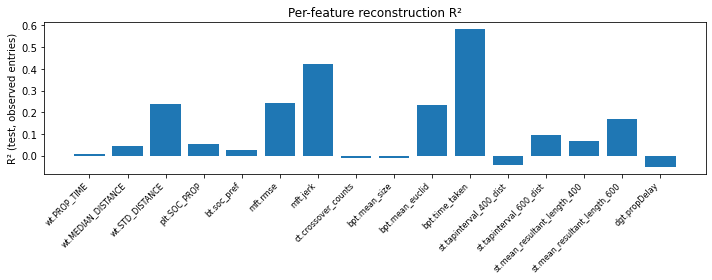

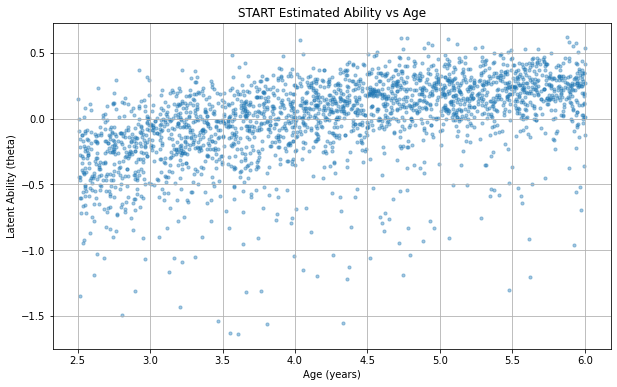

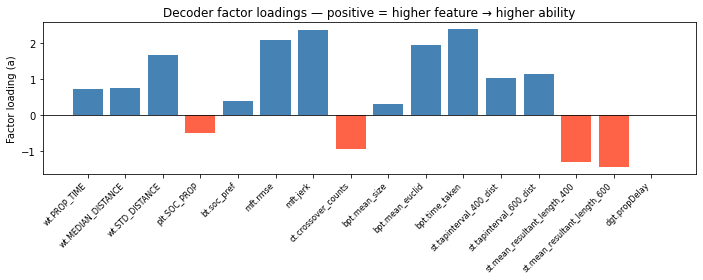

In [34]:
results = train_and_score(inputs, show_plots=SHOW_PLOTS)

In [35]:
score_df = pd.DataFrame({
    "child_ids":      inputs["ids"],
    "Age":            inputs["ages_days"],
    "start_ability":  results["theta_all"],
})

score_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {OUTPUT_PATH}")
score_df.head(10)

Saved start_Deep_ability.csv


,child_ids,Age,start_ability
0,IN-0003-BL,1296.0,0.216211
1,IN-0006-BL,1301.0,-0.057303
2,IN-0011-BL,2037.0,0.379656
3,IN-0015-BL,1447.0,-0.183691
4,IN-0016-BL,1485.0,-0.184384
5,IN-0021-BL,1344.0,-0.154795
6,IN-0022-BL,1345.0,0.043791
7,IN-0029-BL,1209.0,-0.015855
8,IN-0031-BL,1722.0,0.112066
9,IN-0033-BL,1965.0,0.066450


In [36]:
print(f"\n=== Summary ===")
print(f"Children scored: {len(score_df)}")
print(f"Test MSE:        {results['test_mse']:.4f}")
print(f"Mean R²:         {np.nanmean(results['r2_list']):.3f}")
print(f"\nAbility stats:")
print(score_df["start_ability"].describe())

corr = np.corrcoef(inputs["ages_years"], results["theta_all"])[0, 1]
print(f"\nCorr(ability, age): {corr:.3f}")

# Factor loadings table
loadings = results["decoder"].a.detach().cpu().numpy().flatten()
loadings_df = pd.DataFrame({
    "feature":  FEATURE_COLS,
    "loading":  loadings,
}).sort_values("loading", ascending=False)
print("\nFactor loadings (sorted):")
loadings_df


=== Summary ===
Children scored: 2343
Test MSE:        0.8250
Mean R²:         0.129

Ability stats:
count    2343.000000
mean       -0.006628
std         0.316510
min        -1.639005
25%        -0.162775
50%         0.054645
75%         0.214671
max         0.617327
Name: start_ability, dtype: float64

Corr(ability, age): 0.513

Factor loadings (sorted):


,feature,loading
10,bpt.time_taken,2.376734
6,mft.jerk,2.353482
5,mft.rmse,2.092500
9,bpt.mean_euclid,1.942219
2,wt.STD_DISTANCE,1.678041
12,st.tapinterval_600_dist,1.136433
11,st.tapinterval_400_dist,1.025144
1,wt.MEDIAN_DISTANCE,0.747069
0,wt.PROP_TIME,0.723030
4,bt.soc_pref,0.395429


In [37]:
# import numpy as np
# from scipy.stats import pearsonr

# start = pd.read_csv("start_Deep_ability_old.csv")
# start["start_ability"] = -start["start_ability"]
# start.to_csv("start_Deep_ability_old.csv", index=False)

# # Remove missing values
# tmp = start[["Age", "start_ability"]].dropna()

# # Pearson correlation
# r, p = pearsonr(tmp["Age"], tmp["start_ability"])

# # Sample size
# n = len(tmp)

# # Fisher z-transform for 95% CI
# z = np.arctanh(r)
# se = 1 / np.sqrt(n - 3)

# z_low = z - 1.96 * se
# z_high = z + 1.96 * se

# r_low = np.tanh(z_low)
# r_high = np.tanh(z_high)

# print(f"N = {n}")
# print(f"Correlation (r): {r:.4f}")
# print(f"P-value: {p:.4e}")
# print(f"95% CI: [{r_low:.4f}, {r_high:.4f}]")